✅  Loaded student_processed.csv  →  shape: (395, 34)

  4.1  GRADE DISTRIBUTIONS (G1, G2, G3)


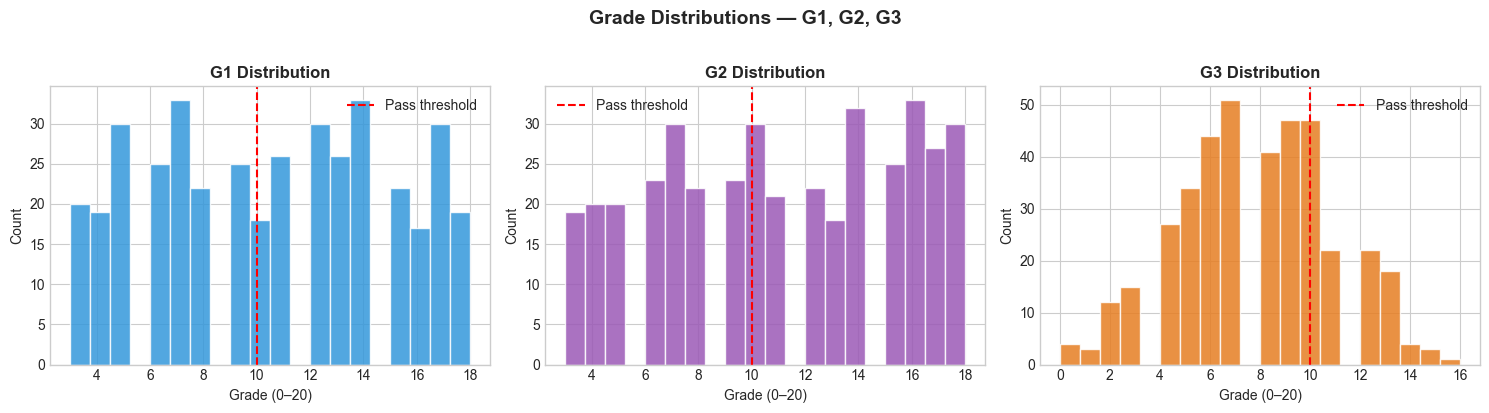

  Plot saved → ../docs/grade_distributions.png
  G1 — mean: 10.50 | std: 4.47 | min: 3 | max: 18
  G2 — mean: 11.01 | std: 4.60 | min: 3 | max: 18
  G3 — mean: 7.72 | std: 3.08 | min: 0 | max: 16

  4.2  STUDY TIME & FAILURES vs PASS RATE


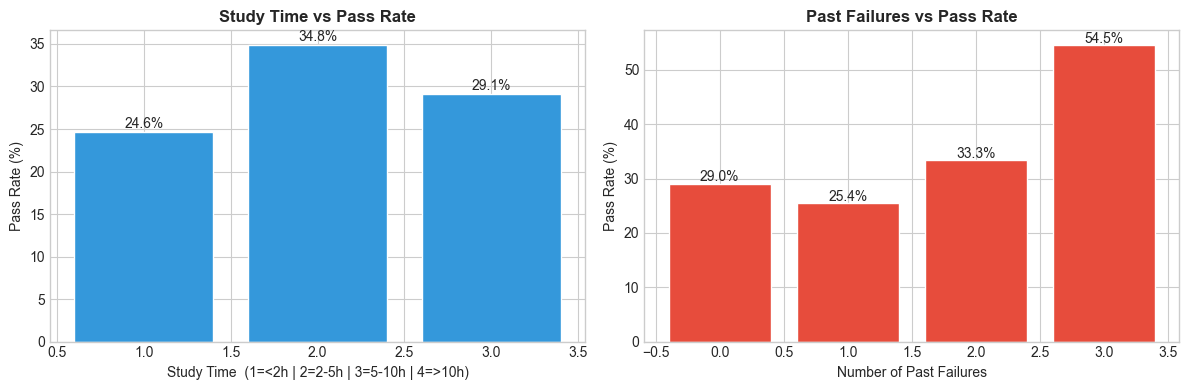

  Plot saved → ../docs/studytime_failures.png

  Study time pass rates:
studytime
1    24.6
2    34.8
3    29.1

  Failures pass rates:
failures
0    29.0
1    25.4
2    33.3
3    54.5

  4.3  CORRELATION HEATMAP


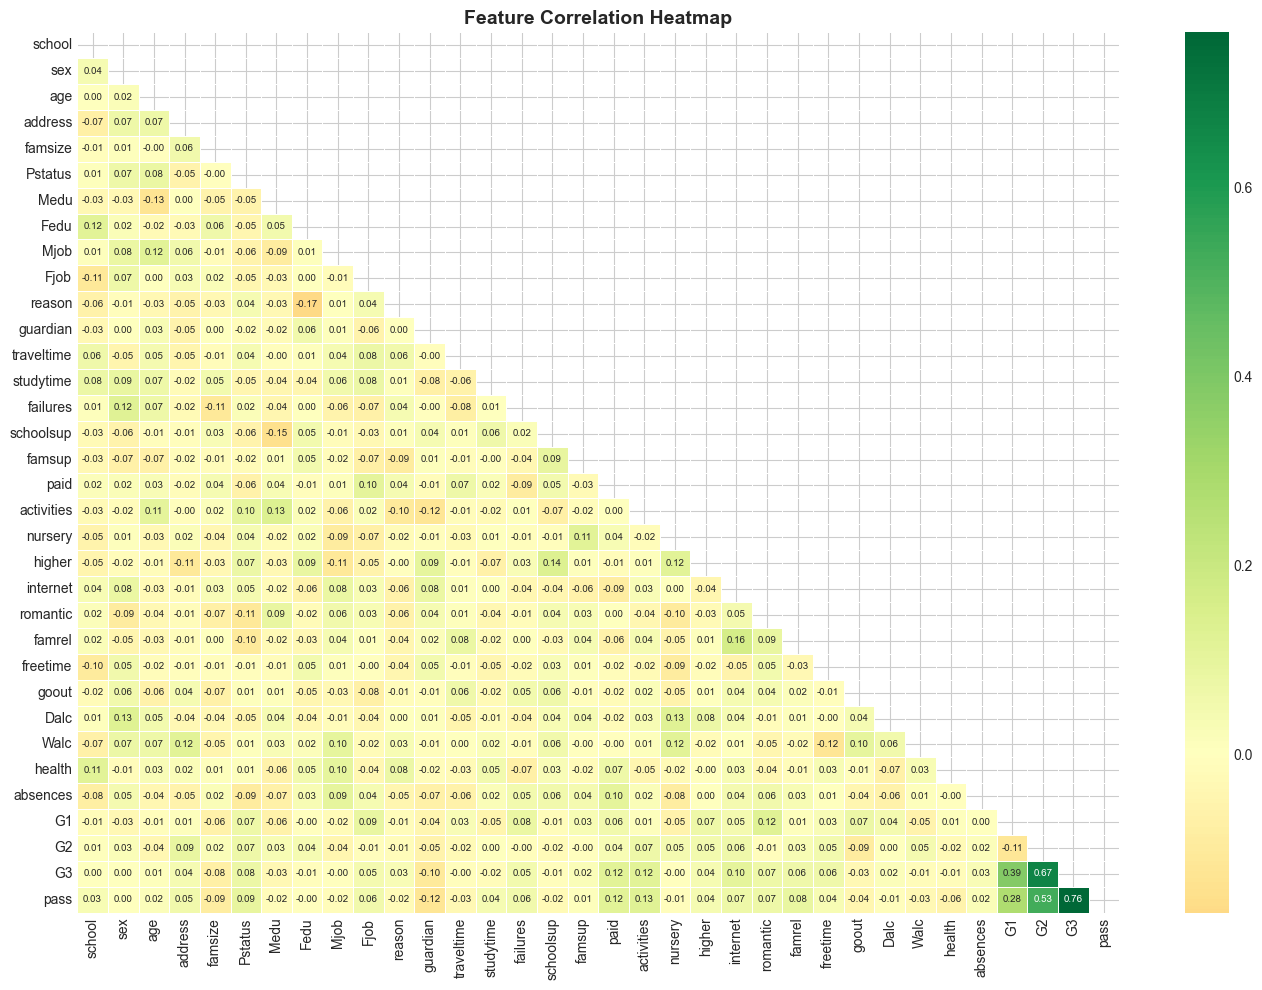

  Plot saved → ../docs/correlation_heatmap.png

  Top 10 features correlated with 'pass':
G3            0.764
G2            0.525
G1            0.280
activities    0.126
guardian      0.119
paid          0.119
Pstatus       0.094
famsize       0.087
famrel        0.084
romantic      0.068

  4.4  ABSENCES & INTERNET vs PASS RATE


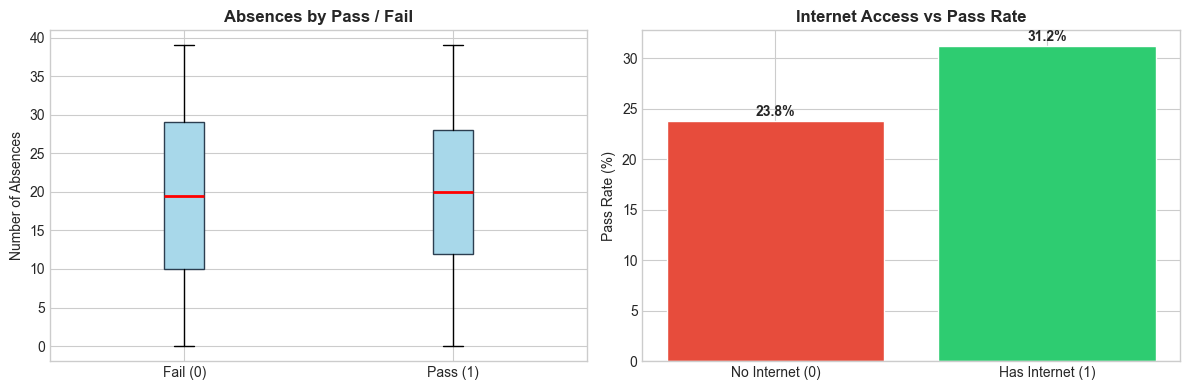

  Plot saved → ../docs/absences_internet.png

  Median absences — Fail: 19.5 | Pass: 20.0
  Internet pass rates:
internet
0    23.8
1    31.2

✅  Stage 4 complete. All EDA plots saved to ../docs/
    Next  : python stage5_feature_engineering.py  (Aparna)


In [1]:
# =============================================================================
# STAGE 4 — Exploratory Data Analysis (EDA)
# -----------------------------------------------------------------------------
# Project: Student Performance Prediction & Early Intervention (#23)
# Team   : Abhi | Aparna | Jia  |  Predictive Analytics 2025-26
# Run    : python stage4_eda.py   (after stage3)
# Input  : ../data/student_processed.csv
# Output : plots saved to ../docs/
# =============================================================================

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

DOCS_DIR = "../docs"
os.makedirs(DOCS_DIR, exist_ok=True)


# ── Load from Stage 3 output ──────────────────────────────────────────────────
def load_data():
    path = "../data/student_processed.csv"
    if not os.path.exists(path):
        raise FileNotFoundError(
            "student_processed.csv not found.\n"
            "Please run stage3_preprocessing.py first."
        )
    df = pd.read_csv(path)
    print(f"✅  Loaded student_processed.csv  →  shape: {df.shape}\n")
    return df


# ── 4.1  Grade Distributions ─────────────────────────────────────────────────
def plot_grade_distributions(df):
    print("=" * 50)
    print("  4.1  GRADE DISTRIBUTIONS (G1, G2, G3)")
    print("=" * 50)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ["#3498db", "#9b59b6", "#e67e22"]
    for i, grade in enumerate(["G1", "G2", "G3"]):
        axes[i].hist(df[grade], bins=20, color=colors[i],
                     edgecolor="white", alpha=0.85)
        axes[i].set_title(f"{grade} Distribution",
                          fontsize=12, fontweight="bold")
        axes[i].set_xlabel("Grade (0–20)")
        axes[i].set_ylabel("Count")
        axes[i].axvline(10, color="red", linestyle="--",
                        linewidth=1.5, label="Pass threshold")
        axes[i].legend()
    plt.suptitle("Grade Distributions — G1, G2, G3",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    out = f"{DOCS_DIR}/grade_distributions.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")

    for g in ["G1", "G2", "G3"]:
        print(f"  {g} — mean: {df[g].mean():.2f} | "
              f"std: {df[g].std():.2f} | "
              f"min: {df[g].min()} | max: {df[g].max()}")


# ── 4.2  Study Time & Failures vs Pass Rate ───────────────────────────────────
def plot_studytime_failures(df):
    print("\n" + "=" * 50)
    print("  4.2  STUDY TIME & FAILURES vs PASS RATE")
    print("=" * 50)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Study time
    studytime_pass = df.groupby("studytime")["pass"].mean() * 100
    axes[0].bar(studytime_pass.index, studytime_pass.values,
                color="#3498db", edgecolor="white")
    axes[0].set_title("Study Time vs Pass Rate", fontweight="bold")
    axes[0].set_xlabel("Study Time  (1=<2h | 2=2-5h | 3=5-10h | 4=>10h)")
    axes[0].set_ylabel("Pass Rate (%)")
    for x, y in zip(studytime_pass.index, studytime_pass.values):
        axes[0].text(x, y + 0.5, f"{y:.1f}%", ha="center", fontsize=10)

    # Past failures
    failures_pass = df.groupby("failures")["pass"].mean() * 100
    axes[1].bar(failures_pass.index, failures_pass.values,
                color="#e74c3c", edgecolor="white")
    axes[1].set_title("Past Failures vs Pass Rate", fontweight="bold")
    axes[1].set_xlabel("Number of Past Failures")
    axes[1].set_ylabel("Pass Rate (%)")
    for x, y in zip(failures_pass.index, failures_pass.values):
        axes[1].text(x, y + 0.5, f"{y:.1f}%", ha="center", fontsize=10)

    plt.tight_layout()
    out = f"{DOCS_DIR}/studytime_failures.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")
    print(f"\n  Study time pass rates:\n{studytime_pass.round(1).to_string()}")
    print(f"\n  Failures pass rates:\n{failures_pass.round(1).to_string()}")


# ── 4.3  Correlation Heatmap ──────────────────────────────────────────────────
def plot_correlation_heatmap(df):
    print("\n" + "=" * 50)
    print("  4.3  CORRELATION HEATMAP")
    print("=" * 50)
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    corr = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap="RdYlGn", center=0, ax=ax,
                linewidths=0.5, annot_kws={"size": 7})
    ax.set_title("Feature Correlation Heatmap",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    out = f"{DOCS_DIR}/correlation_heatmap.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")

    # Top correlations with target
    target_corr = corr["pass"].drop("pass").abs().sort_values(ascending=False)
    print("\n  Top 10 features correlated with 'pass':")
    print(target_corr.head(10).round(3).to_string())


# ── 4.4  Absences & Internet vs Pass ─────────────────────────────────────────
def plot_absences_internet(df):
    print("\n" + "=" * 50)
    print("  4.4  ABSENCES & INTERNET vs PASS RATE")
    print("=" * 50)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Absences boxplot
    pass_0 = df[df["pass"] == 0]["absences"]
    pass_1 = df[df["pass"] == 1]["absences"]
    axes[0].boxplot(
        [pass_0, pass_1],
        labels=["Fail (0)", "Pass (1)"],
        patch_artist=True,
        boxprops=dict(facecolor="#a8d8ea", color="#2c3e50"),
        medianprops=dict(color="red", linewidth=2)
    )
    axes[0].set_title("Absences by Pass / Fail", fontweight="bold")
    axes[0].set_ylabel("Number of Absences")

    # Internet access
    internet_pass = df.groupby("internet")["pass"].mean() * 100
    labels = ["No Internet (0)", "Has Internet (1)"]
    axes[1].bar(labels, internet_pass.values,
                color=["#e74c3c", "#2ecc71"], edgecolor="white")
    axes[1].set_title("Internet Access vs Pass Rate", fontweight="bold")
    axes[1].set_ylabel("Pass Rate (%)")
    for i, v in enumerate(internet_pass.values):
        axes[1].text(i, v + 0.5, f"{v:.1f}%",
                     ha="center", fontweight="bold")

    plt.tight_layout()
    out = f"{DOCS_DIR}/absences_internet.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot saved → {out}")
    print(f"\n  Median absences — Fail: {pass_0.median():.1f} | "
          f"Pass: {pass_1.median():.1f}")
    print(f"  Internet pass rates:\n{internet_pass.round(1).to_string()}")


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    df = load_data()
    plot_grade_distributions(df)
    plot_studytime_failures(df)
    plot_correlation_heatmap(df)
    plot_absences_internet(df)

    print(f"\n✅  Stage 4 complete. All EDA plots saved to {DOCS_DIR}/")
    print("    Next  : python stage5_feature_engineering.py  (Aparna)")
